<a href="https://colab.research.google.com/github/Mehtabul-Islam/CSE422---artificial-intelligence/blob/main/LAB%2001/Assisgnment_1_Solution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CSE422 Lab 01: A* Search
Md. Mehtabul Islam | 24301400

## Part 1
**Description:**

**Task:** You are to write the program of a Maze Solver Agent to find a path through a maze from an entry point to an exit point using the $A^*$ search algorithm.

**Maze:** For this task, the maze is of size $N \times M$, where $N$ is the height and $M$ is the width of the maze. The maze is described using 2 symbols, `0` and `#`, where `0`s denote the paths and `#`s denote the walls. In addition, the mazes will have only one entry point and only one exit point.

**Heuristic function:** You need to use the Manhattan distance as the heuristic function. For two points $(x_1, y_1)$ and $(x_2, y_2)$, the Manhattan distance is calculated as $\vert{}x_1 - x_2\vert{} + \vert{}y_1 - y_2\vert{}$.

**Moves:** The agent can move only in horizontal and vertical directions. It cannot move in diagonal directions.

**Cost:** The cost of each move in the maze is 1.

### Input Format:
* The first line contains two integers $n, m$ – height and width of the maze.
* The second line contains two integers $a, b$ – index of the entry point of the maze.
* The third line contains two integers $c, d$ – index of the exit point of the maze.
* The following $n$ lines contain $m$ characters – description of the maze.

### Output Format:
* The first output will be the total path cost (number of steps required to exit the maze).
* The second output will be the sequence of actions to go from initial to goal state [it will contain a sequence of actions represented using the characters U (Up), D (Down), R (Right), and L (Left). Print -1 if no path is found].

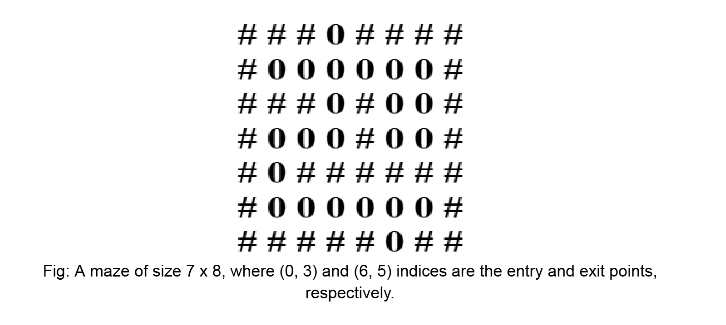

### Sample 1:
**Input:**
```text
7 8
0 3
6 5
# # # 0 # # # #
# 0 0 0 0 0 0 #
# # # 0 # 0 0 #
# 0 0 0 # 0 0 #
# 0 # # # # # #
# 0 0 0 0 0 0 #
# # # # # 0 # #

**Output:**
```text
12
DDDLLDDRRRRD

### Sample 2:
**Input:**
```text
10 12
0 1
9 8
# 0 # # # # # # # # # #
# 0 0 0 0 0 0 # # # 0 #
# # # 0 # # # 0 # # 0 #
# 0 # 0 # 0 0 0 # # 0 #
# 0 # 0 # # # 0 # # 0 #
# 0 0 0 0 # 0 0 # # 0 #
# # # 0 # # # 0 # # 0 #
# 0 0 0 # 0 0 0 0 # 0 #
# 0 # # # # # 0 0 0 0 #
# # # # # # # 0 # # # #

**Output:**
```text
-1

### Sample 3:
**Input:**
```text
15 15
1 0
13 14
# # # # # # # # # # # # # # #
0 0 0 0 # # # # # # # # # 0 #
# # # 0 # # # # # 0 0 # # 0 #
# 0 0 0 0 0 0 0 0 # 0 # # 0 #
# 0 # # # # # # 0 # # # # 0 #
# 0 # # # # # # 0 # 0 # # 0 #
# 0 0 0 0 0 0 0 0 0 0 0 0 0 #
# # # # # # # # # # 0 # # # #
# 0 # # # # # # 0 0 0 # # # #
# 0 # # # # # # 0 0 0 0 0 0 #
# 0 # # # # # # # # # # 0 0 #
# 0 0 0 0 0 0 0 0 0 0 0 0 0 #
# # # 0 # # # # # # # 0 # # #
# 0 0 0 0 0 0 0 0 0 0 0 0 0 0
# # # # # # # # # # # # # # #

**Output:**
```text
28
RRRDDRRRRRDDDRRDDDRRDDLDDRRR

# **SOLVE**

In [7]:
import heapq

def solve_maze_a_star(input_data):
    # Split the input data into lines and remove empty lines
    lines = [line.strip() for line in input_data.strip().split('\n') if line.strip()]
    if not lines:
        return

    # Parse dimensions, start, and goal
    n, m = map(int, lines[0].split())
    start_x, start_y = map(int, lines[1].split())
    goal_x, goal_y = map(int, lines[2].split())

    # Parse the maze layout
    maze = lines[3:3+n]

    # Heuristic function: Manhattan Distance
    def h(x, y):
        return abs(x - goal_x) + abs(y - goal_y)

    # Priority Queue for A* Search. Stores tuples of (f, g, x, y, path_string)
    pq = []
    heapq.heappush(pq, (h(start_x, start_y), 0, start_x, start_y, ""))

    # Keep track of visited nodes to prevent cyclic loops
    visited = set()

    # Dictionary mapping directions to coordinate changes
    # Ensure standard order: U, D, L, R
    directions = { 'U': (-1, 0), 'D': (1, 0), 'L': (0, -1), 'R': (0, 1) }

    while pq:
        f, g, x, y, path = heapq.heappop(pq)

        # Goal check
        if (x, y) == (goal_x, goal_y):
            print(g)
            print(path)
            return

        # Skip if already visited
        if (x, y) in visited:
            continue
        visited.add((x, y))

        # Explore all 4 neighbors
        for move, (dx, dy) in directions.items():
            nx, ny = x + dx, y + dy

            # Check bounds and if the next cell is a valid path ('0')
            if 0 <= nx < n and 0 <= ny < m and maze[nx][ny] == '0':
                if (nx, ny) not in visited:
                    next_g = g + 1
                    next_f = next_g + h(nx, ny)
                    heapq.heappush(pq, (next_f, next_g, nx, ny, path + move))

    # Output if no path is found
    print("-1")

# ==========================================
# PASTE YOUR INPUT BETWEEN THE TRIPLE QUOTES
# ==========================================
print("--- Sample 1 Output ---")
sample_input = """
7 8
0 3
6 5
###0####
#000000#
###0#00#
#000#00#
#0######
#000000#
#####0##
"""

# Run the solver
solve_maze_a_star(sample_input)

print("\n--- Sample 2 Output ---")
sample_input = """
10 12
0 1
9 8
#0##########
#000000###0#
###0###0##0#
#0#0#000##0#
#0#0###0##0#
#0000#00##0#
###0###0##0#
#000#0000#0#
#0#####0000#
#######0####
"""
# Run the solver
solve_maze_a_star(sample_input)

print("\n--- Sample 3 Output ---")
sample_input = """
15 15
1 0
13 14
###############
0000#########0#
###0#####00##0#
#00000000#0##0#
#0######0####0#
#0######0#0##0#
#0000000000000#
##########0####
#0######000####
#0######000000#
#0##########00#
#0000000000000#
###0#######0###
#00000000000000
###############
"""
# Run the solver
solve_maze_a_star(sample_input)

--- Sample 1 Output ---
12
DDDLLDDRRRRD

--- Sample 2 Output ---
-1

--- Sample 3 Output ---
28
RRRDDRRRRRDDDRRDDDRRDDLDDRRR
